In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import sys
import met_brewer as mb

sys.path.append('../')
from utils import *
from plotting_helper_funcs import *

%matplotlib inline
plt.style.use('~/.matplotlib/stylelib/custom.mplstyle')
mpl.rcParams['figure.autolayout'] = True

color_dict = get_compartment_colors()

We want to load the data from the Schimtt et al. exeriments. The authors provide an excell file where each sheet is the data show in each figure.
This file is `../../../Schmitt_et_al_2022_data/Numerical_Source_data.xlsx`. We parse the data from figure 2 into a new file `../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx` to ease loading via pandas.

Note that the following Fig 2 panels have the noted correspondence:
- 2b - WT ExRai-AMPKAR at the Lysosome 
- 2c - WT ExRai-AMPKAR at the Mitochondria
- 2d - WT ExRai-AMPKAR at the Cytoplasm

Next, we load the sheets as pandas data frames, keeping only the rows and columns with the times, WT mean, and WT STDEV.

In [14]:
# fig 2b - lysosome data
lyso_df = pd.read_excel('../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx', 
                          sheet_name='Figure 2b', skiprows=5, usecols='A:C', 
                          names=['Time (min)', 'WT MEAN', 'WT SDEV'])
# fig 2c - mitochondria data
mito_df = pd.read_excel('../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx', 
                          sheet_name='Figure 2c', skiprows=5, usecols='A:C', 
                          names=['Time (min)', 'WT MEAN', 'WT SDEV'])
# fig 2e - cytoplasm data (also contains LKB1 KD data)
cyto_df = pd.read_excel('../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx', 
                          sheet_name='Figure 2e', skiprows=5, usecols='A:E', 
                          names=['Time (min)', 'WT MEAN', 'WT SDEV', 'LKB1 KD MEAN', 'LKB1 KD SDEV'])
# fig 2f - lyso LKB1 KO data
lyso_2f = pd.read_excel('../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx',
                        sheet_name='Figure 2f', skiprows=5, usecols='A:E', 
                        names=['Time (min)', 'WT MEAN', 'WT SDEV', 'LKB1 KD MEAN', 'LKB1 KD SDEV'])
# fig 2g - mito LKB1 KO data
mito_2g = pd.read_excel('../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx',
                        sheet_name='Figure 2g', skiprows=5, usecols='A:E', 
                        names=['Time (min)', 'WT MEAN', 'WT SDEV', 'LKB1 KD MEAN', 'LKB1 KD SDEV'])


Note that the data given contain $\bar{R}(t)$ which is the mean over $N$ cells over time and $\sigma_{R}(t)$ which is the standard deviation over $N$ cells over time. 

We normalize the data such that we can relate the normalized measurements to the ratio of phosphorylated to unphosphorylated sensor (following the advice of Greenwald et al. 2014).
First we compute the min and max of $\bar{R}(t)$. Then we compute normalized ratio, which is defined
$$
R_{\rm norm}(t) \equiv \frac{\bar{R}(t) - R_{\rm min}}{R_{\rm max} - R_{\rm min}},
$$
which is equivalent to normalizing the data from each cell to min and max of the average of all cells.

Next, we need to normalize the standard deviation. We use the following formula
$$
\sigma^2_{R_{\rm norm}}(t) = \frac{\sigma^2_{R}(t)}{(R_{\rm max} - R_{\rm min})^2}
$$
which comes from computing the variance of the normalized data.

For the **LKB1 knockdown data** we will normalize to the WT measurements in the respective compartment. There is a slight dilemma here with the mitochondria LKB1 KD data. The max ratio is high in the KD case (although not statistically significant), so when we use the WT values for normalization the ratio is higher than 1. 
For the mitochondria LKB1 KD data, we will normalize to the KD data and not to the WT data

In [15]:
# function to normalize data mean and standard deviation
def compute_normalized_data_WT(df):
    """ Normalize data mean and standard deviation """
    norm_mean = (df['WT MEAN'] - df['WT MEAN'].min()) / (df['WT MEAN'].max() - df['WT MEAN'].min())
    norm_sd = df['WT SDEV'] / (df['WT MEAN'].max() - df['WT MEAN'].min())
    return norm_mean, norm_sd

def compute_normalized_data_LKB1_KD(df):
    """ Normalize data mean and standard deviation """
    # check if df contains LKB1 KD data
    if 'LKB1 KD MEAN' not in df.columns or 'LKB1 KD SDEV' not in df.columns:
        raise ValueError("DataFrame must contain 'LKB1 KD MEAN' and 'LKB1 KD SDEV' columns")
    
    norm_mean = (df['LKB1 KD MEAN'] - df['WT MEAN'].min()) / (df['WT MEAN'].max() - df['WT MEAN'].min())
    norm_sd = df['LKB1 KD SDEV'] / (df['WT MEAN'].max() - df['WT MEAN'].min())
    return norm_mean, norm_sd

# noramlize WT data
norm_cyto, norm_cyto_sd = compute_normalized_data_WT(cyto_df)
norm_lyso, norm_lyso_sd = compute_normalized_data_WT(lyso_df)
norm_mito, norm_mito_sd = compute_normalized_data_WT(mito_df)

# normalize LKB1 KD data
norm_cyto_LKB1_KD, norm_cyto_LKB1_KD_sd = compute_normalized_data_LKB1_KD(cyto_df)
norm_lyso_LKB1_KD, norm_lyso_LKB1_KD_sd = compute_normalized_data_LKB1_KD(lyso_2f)
norm_mito_LKB1_KD, norm_mito_LKB1_KD_sd = compute_normalized_data_LKB1_KD(mito_2g)

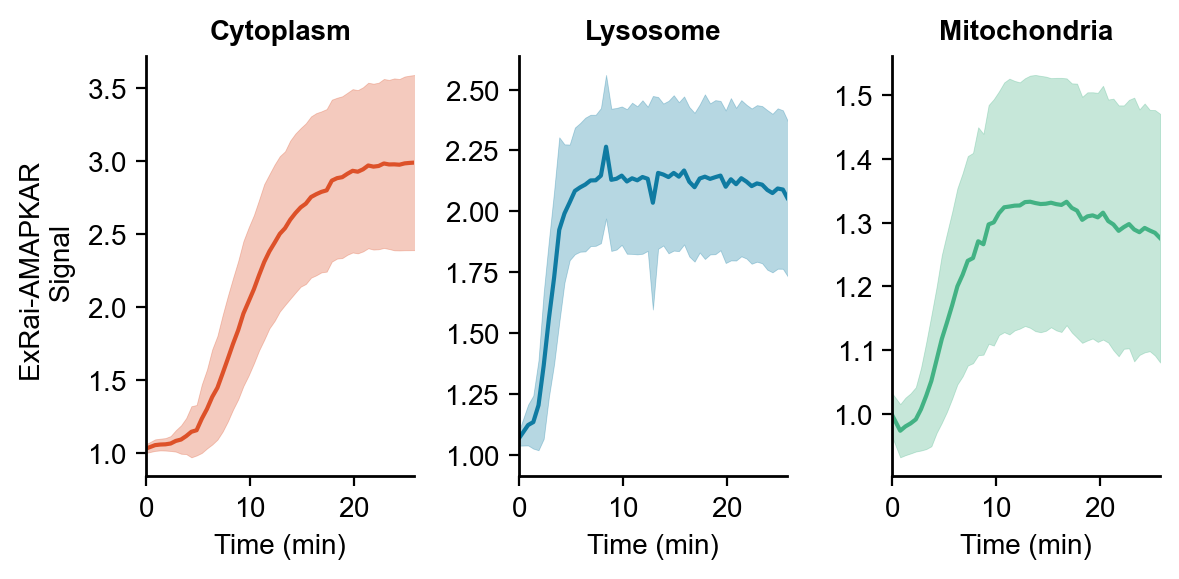

In [16]:
# make a plot of raw data
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(6, 3))
ax[0].plot(cyto_df['Time (min)'], cyto_df["WT MEAN"], label='cytoplasm', color=color_dict['cyto'])
ax[0].fill_between(cyto_df['Time (min)'], cyto_df["WT MEAN"] + cyto_df["WT SDEV"], cyto_df["WT MEAN"] - cyto_df["WT SDEV"], alpha=0.3, color=color_dict['cyto'])
ax[1].plot(lyso_df['Time (min)'], lyso_df["WT MEAN"], label='lysosome', color=color_dict['lyso'])
ax[1].fill_between(lyso_df['Time (min)'], lyso_df["WT MEAN"] + lyso_df["WT SDEV"], lyso_df["WT MEAN"] - lyso_df["WT SDEV"], alpha=0.3, color=color_dict['lyso'])
ax[2].plot(mito_df['Time (min)'], mito_df["WT MEAN"], label='mitochondria', color=color_dict['mito'])
ax[2].fill_between(mito_df['Time (min)'], mito_df["WT MEAN"] + mito_df["WT SDEV"], mito_df["WT MEAN"] - mito_df["WT SDEV"], alpha=0.3, color=color_dict['mito'])
# ax.legend(loc='upper left')
ax[0].set_ylabel('ExRai-AMAPKAR \n Signal', fontsize=10)

titles = ['Cytoplasm', 'Lysosome', 'Mitochondria']
for i in range(3):
    ax[i].set_xlabel('Time (min)', fontsize=10)
    ax[i].set_xlim([0.0, 25.8])
    ax[i].set_title(titles[i], fontsize=10)

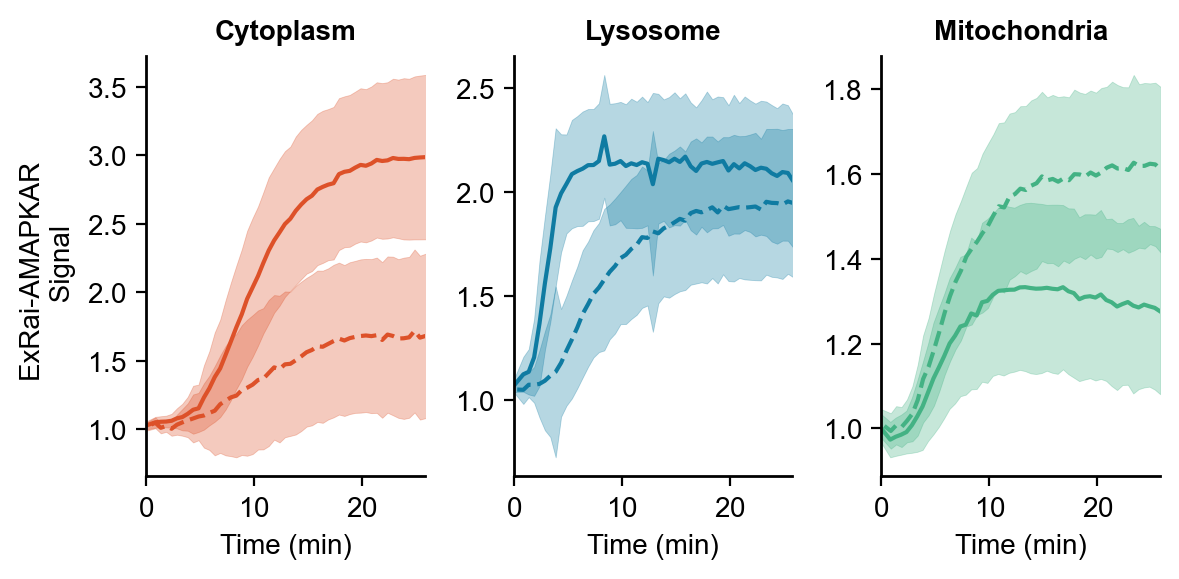

In [17]:
# make a plot of raw data
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(6, 3))

ax[0].plot(cyto_df['Time (min)'], cyto_df["WT MEAN"], label='cytoplasm', color=color_dict['cyto'])
ax[0].fill_between(cyto_df['Time (min)'], cyto_df["WT MEAN"] + cyto_df["WT SDEV"], cyto_df["WT MEAN"] - cyto_df["WT SDEV"], alpha=0.3, color=color_dict['cyto'])
ax[1].plot(lyso_df['Time (min)'], lyso_df["WT MEAN"], label='lysosome', color=color_dict['lyso'])
ax[1].fill_between(lyso_df['Time (min)'], lyso_df["WT MEAN"] + lyso_df["WT SDEV"], lyso_df["WT MEAN"] - lyso_df["WT SDEV"], alpha=0.3, color=color_dict['lyso'])
ax[2].plot(mito_df['Time (min)'], mito_df["WT MEAN"], label='mitochondria', color=color_dict['mito'])
ax[2].fill_between(mito_df['Time (min)'], mito_df["WT MEAN"] + mito_df["WT SDEV"], mito_df["WT MEAN"] - mito_df["WT SDEV"], alpha=0.3, color=color_dict['mito'])

ax[0].plot(cyto_df['Time (min)'], cyto_df["LKB1 KD MEAN"], label='cytoplasm', color=color_dict['cyto'], linestyle='--')
ax[0].fill_between(cyto_df['Time (min)'], cyto_df["LKB1 KD MEAN"] + cyto_df["WT SDEV"], cyto_df["LKB1 KD MEAN"] - cyto_df["WT SDEV"], alpha=0.3, color=color_dict['cyto'])
ax[1].plot(lyso_2f['Time (min)'], lyso_2f["LKB1 KD MEAN"], label='lysosome', color=color_dict['lyso'], linestyle='--')
ax[1].fill_between(lyso_2f['Time (min)'], lyso_2f["LKB1 KD MEAN"] + lyso_2f["WT SDEV"], lyso_2f["LKB1 KD MEAN"] - lyso_2f["WT SDEV"], alpha=0.3, color=color_dict['lyso'])
ax[2].plot(mito_2g['Time (min)'], mito_2g["LKB1 KD MEAN"], label='mitochondria', color=color_dict['mito'], linestyle='--')
ax[2].fill_between(mito_2g['Time (min)'], mito_2g["LKB1 KD MEAN"] + mito_2g["WT SDEV"], mito_2g["LKB1 KD MEAN"] - mito_2g["WT SDEV"], alpha=0.3, color=color_dict['mito'])
# ax.legend(loc='upper left')
ax[0].set_ylabel('ExRai-AMAPKAR \n Signal', fontsize=10)

titles = ['Cytoplasm', 'Lysosome', 'Mitochondria']
for i in range(3):
    ax[i].set_xlabel('Time (min)', fontsize=10)
    ax[i].set_xlim([0.0, 25.8])
    ax[i].set_title(titles[i], fontsize=10)

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_62764/3572387920.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(f'../../../Schmitt_et_al_2022_data/fig_2_{comp}_norm_WT.pdf')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_62764/3572387920.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(f'../../../Schmitt_et_al_2022_data/fig_2_{comp}_norm_WT.pdf')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_62764/3572387920.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(f'../../../Schmitt_et_al_2022_data/fig_2_{comp}_norm_WT.pdf')
/Users/natetest/miniforge3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so re

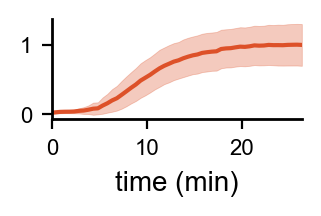

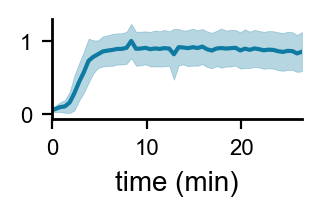

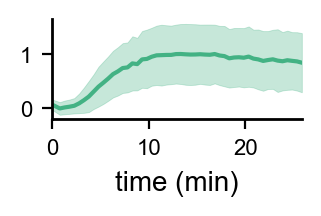

In [18]:
# make plots of normalized data - to use in paper
fig_width, fig_height = 1.25, 0.5
fig_cyto, ax_cyto = get_sized_fig_ax(fig_width, fig_height)
fig_lyso, ax_lyso = get_sized_fig_ax(fig_width, fig_height)
fig_mito, ax_mito = get_sized_fig_ax(fig_width, fig_height)

dat = {'cyto':{'times':cyto_df['Time (min)'], 'norm_mean':norm_cyto, 'norm_sd':norm_cyto_sd, 'fig_ax':(fig_cyto, ax_cyto)},
       'lyso':{'times':lyso_df['Time (min)'], 'norm_mean':norm_lyso, 'norm_sd':norm_lyso_sd, 'fig_ax':(fig_lyso, ax_lyso)},
        'mito':{'times':mito_df['Time (min)'], 'norm_mean':norm_mito, 'norm_sd':norm_mito_sd, 'fig_ax':(fig_mito, ax_mito)}}

for comp in dat.keys():
    fig, ax = dat[comp]['fig_ax']
    ax.plot(dat[comp]['times'], dat[comp]['norm_mean'], label=comp, 
            color=color_dict[comp])
    ax.fill_between(dat[comp]['times'], dat[comp]['norm_mean'] + dat[comp]['norm_sd'], 
                    dat[comp]['norm_mean'] - dat[comp]['norm_sd'], alpha=0.3, 
                    color=color_dict[comp])
    ax.set_xlabel('time (min)', fontsize=10)
#     ax.set_ylabel('Normalized ExRai-AMAPKAR \n Signal')
    ax.set_xlim([0.0, np.max(dat[comp]['times'])])

    ax.set_xticks([0, 10, 20])
    ax.set_xticklabels(['0', '10', '20'], fontsize=8)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['0', '1'], fontsize=8)
    
    fig.savefig(f'../../../Schmitt_et_al_2022_data/fig_2_{comp}_norm_WT.pdf')


In [19]:
# save all of the renormalized data
np.savez('../../../Schmitt_et_al_2022_data/fig_2b_lyso.npz', times=lyso_df['Time (min)'].to_numpy(), 
         mean=norm_lyso.to_numpy(), std=norm_lyso_sd.to_numpy(), 
         std_constant=norm_lyso_sd.mean())
np.savez('../../../Schmitt_et_al_2022_data/fig_2c_mito.npz', times=mito_df['Time (min)'].to_numpy(), 
         mean=norm_mito.to_numpy(), std=norm_mito_sd.to_numpy(), 
         std_constant=norm_mito_sd.mean())
np.savez('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz', times=cyto_df['Time (min)'].to_numpy(), 
         mean=norm_cyto.to_numpy(), std=norm_cyto_sd.to_numpy(), 
         std_constant=norm_cyto_sd.mean())

np.savez('../../../Schmitt_et_al_2022_data/fig_2f_lyso_LKB1_KD.npz', times=lyso_df['Time (min)'].to_numpy(), 
         mean=norm_lyso_LKB1_KD.to_numpy(), std=norm_lyso_LKB1_KD_sd.to_numpy(), 
         std_constant=norm_lyso_LKB1_KD_sd.mean())
np.savez('../../../Schmitt_et_al_2022_data/fig_2g_mito_LKB1_KD.npz', times=mito_df['Time (min)'].to_numpy(), 
         mean=norm_mito_LKB1_KD.to_numpy(), std=norm_mito_LKB1_KD_sd.to_numpy(), 
         std_constant=norm_mito_LKB1_KD_sd.mean())
np.savez('../../../Schmitt_et_al_2022_data/fig_2e_cyto_LKB1_KD.npz', times=cyto_df['Time (min)'].to_numpy(), 
         mean=norm_cyto_LKB1_KD.to_numpy(), std=norm_cyto_LKB1_KD_sd.to_numpy(), 
         std_constant=norm_cyto_LKB1_KD_sd.mean())